# Compare NeuralLaplace encoder train modes

Этот ноутбук сравнивает 3 варианта `ENCODER_TRAIN_DATA_MODE`:
- `all`
- `random_half`
- `time_half`


## 1) Imports


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from run_benchmark import load_dataset
from bandit_benchmark import (
    NeuralLaplaceThompsonViaBayesianLogRegPolicy,
    RandomPolicy,
    core_scenarios,
    default_five_scenarios,
    run_scenarios,
)
from prepare_datasets import stage1_make_splits, stage2_scale_features


## 2) Config


In [3]:
DATA_PATH = ROOT / 'data' / 'banner_small.tsv'
DATASET_NAME = DATA_PATH.stem
ARTIFACTS_DIR = ROOT / 'artifacts' / DATASET_NAME
DATASETS_DIR = ARTIFACTS_DIR / 'datasets'

PREPARED_TRAIN_PATH = DATASETS_DIR / 'train_variant_1_scaled.parquet'
PREPARED_TEST_PATH = DATASETS_DIR / 'test_variant_1_scaled.parquet'

USE_PREPARED_SPLITS = True
TRAIN_DAYS = 1
SEED = 42
FULL_SCENARIOS = False

# neural params
NEURAL_HIDDEN_DIMS = [128, 64]
NN_EPOCHS = 10
NN_BATCH_SIZE = 256
ENCODER_REP_DIM = 32
ENCODER_NN_LR = 1e-3


## 3) Load / prepare dataset


In [4]:
if USE_PREPARED_SPLITS and PREPARED_TRAIN_PATH.exists() and PREPARED_TEST_PATH.exists():
    train_df = pl.read_parquet(PREPARED_TRAIN_PATH)
    test_df = pl.read_parquet(PREPARED_TEST_PATH)
    print('loaded prepared splits')
else:
    train_s1, test_s1 = stage1_make_splits(str(DATA_PATH), str(DATASETS_DIR), TRAIN_DAYS, SEED)
    train_final, test_final = stage2_scale_features(train_s1, test_s1, str(DATASETS_DIR))
    train_df = pl.read_parquet(train_final)
    test_df = pl.read_parquet(test_final)

print('train:', train_df.height, 'test(random only):', test_df.height)


loaded prepared splits
train: 574072 test(random only): 977239


In [ ]:
feature_rows = train_df.select('features_list').to_series().to_list()
non_empty_features = [row for row in feature_rows if isinstance(row, list) and len(row) > 0]
if non_empty_features:
    feature_dim = len(non_empty_features[0])
    action_count = train_df.select('show').n_unique()
    custom_encoder = _NeuralActionRewardEncoder(
        input_dim=feature_dim,
        num_actions=action_count,
        hidden_dims=NEURAL_HIDDEN_DIMS,
        rep_dim=ENCODER_REP_DIM,
        lr=ENCODER_NN_LR,
        se

## 4) Compare 3 encoder modes


In [4]:
policy_factories = {
    'neural_all': lambda: NeuralLaplaceThompsonViaBayesianLogRegPolicy(
        seed=SEED,
        network_architecture=NEURAL_HIDDEN_DIMS,
        encoder_train_data_mode='all',
        nn_epochs=NN_EPOCHS,
        nn_batch_size=NN_BATCH_SIZE,
    ),
    'neural_random_half': lambda: NeuralLaplaceThompsonViaBayesianLogRegPolicy(
        seed=SEED,
        network_architecture=NEURAL_HIDDEN_DIMS,
        encoder_train_data_mode='random_half',
        nn_epochs=NN_EPOCHS,
        nn_batch_size=NN_BATCH_SIZE,
    ),
    'neural_time_half': lambda: NeuralLaplaceThompsonViaBayesianLogRegPolicy(
        seed=SEED,
        network_architecture=NEURAL_HIDDEN_DIMS,
        encoder_train_data_mode='time_half',
        nn_epochs=NN_EPOCHS,
        nn_batch_size=NN_BATCH_SIZE,
    ),
    # optional reference baseline
    'random': lambda: RandomPolicy(seed=SEED),
}

scenarios = default_five_scenarios() if FULL_SCENARIOS else core_scenarios()

result = run_scenarios(
    train_df=train_df,
    test_df=test_df,
    policy_factories=policy_factories,
    scenarios=scenarios,
    env_reward=None,
    show_progress=True,
)

metrics_df = result['metrics']
history_df = result['history']

display(metrics_df.sort_values(['scenario', 'ips_ctr'], ascending=[True, False]).reset_index(drop=True))


case_2_random_pretrain_online_update_daily/neural_all:   0%|

case_2_random_pretrain_online_update_daily/neural_all: train_unique_actions=25


case_2_random_pretrain_online_update_daily/neural_random_hal

case_2_random_pretrain_online_update_daily/neural_random_half: train_unique_actions=25


case_2_random_pretrain_online_update_daily/neural_time_half:

...

case_2b_random_pretrain_online_update_step_2p5/neural_time_h

case_2b_random_pretrain_online_update_step_2p5/neural_time_half: train_unique_actions=25


case_2b_random_pretrain_online_update_step_2p5/random:   0%|

case_2b_random_pretrain_online_update_step_2p5/random: train_unique_actions=25


,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens,scenario,algo
0,977239,543437,4416.0,0.008126,8544.0,0.008743,0.556094,318.405447,0.000586,5048.920327,0.005167,698173,0.009238,0.007233,case_2_random_pretrain_online_update_daily,neural_random_half
1,977239,543112,4419.0,0.008136,8522.0,0.008720,0.555762,313.188419,0.000577,5045.920327,0.005163,698173,0.009207,0.007229,case_2_random_pretrain_online_update_daily,neural_time_half
2,977239,543154,4411.0,0.008121,8498.0,0.008696,0.555805,322.954079,0.000595,5053.920327,0.005172,698173,0.009173,0.007240,case_2_random_pretrain_online_update_daily,neural_all
3,977239,544376,3895.0,0.007155,6867.0,0.007027,0.557055,854.504461,0.001570,5569.920327,0.005700,698173,0.006836,0.007979,case_2_random_pretrain_online_update_daily,random
4,977239,543654,4414.0,0.008119,8534.0,0.008733,0.556316,322.333796,0.000593,5050.920327,0.005169,698173,0.009224,0.007236,case_2b_random_pretrain_online_update_step_2p5,neural_random_half
5,977239,542999,4407.0,0.008116,8500.0,0.008698,0.555646,327.339408,0.000603,5057.920327,0.005176,698173,0.009175,0.007246,case_2b_random_pretrain_online_update_step_2p5,neural_all
6,977239,543594,4406.0,0.008105,8471.0,0.008668,0.556255,332.116401,0.000611,5058.920327,0.005177,698173,0.009134,0.007248,case_2b_random_pretrain_online_update_step_2p5,neural_time_half
7,977239,544376,3895.0,0.007155,6867.0,0.007027,0.557055,854.504461,0.001570,5569.920327,0.005700,698173,0.006836,0.007979,case_2b_random_pretrain_online_update_step_2p5,random


## 5) Focus table: only neural variants


In [5]:
neural_metrics = metrics_df[metrics_df['algo'].str.startswith('neural_')].copy()
display(neural_metrics.sort_values(['scenario', 'ips_ctr'], ascending=[True, False]).reset_index(drop=True))


,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens,scenario,algo
0,977239,543437,4416.0,0.008126,8544.0,0.008743,0.556094,318.405447,0.000586,5048.920327,0.005167,698173,0.009238,0.007233,case_2_random_pretrain_online_update_daily,neural_random_half
1,977239,543112,4419.0,0.008136,8522.0,0.008720,0.555762,313.188419,0.000577,5045.920327,0.005163,698173,0.009207,0.007229,case_2_random_pretrain_online_update_daily,neural_time_half
2,977239,543154,4411.0,0.008121,8498.0,0.008696,0.555805,322.954079,0.000595,5053.920327,0.005172,698173,0.009173,0.007240,case_2_random_pretrain_online_update_daily,neural_all
3,977239,543654,4414.0,0.008119,8534.0,0.008733,0.556316,322.333796,0.000593,5050.920327,0.005169,698173,0.009224,0.007236,case_2b_random_pretrain_online_update_step_2p5,neural_random_half
4,977239,542999,4407.0,0.008116,8500.0,0.008698,0.555646,327.339408,0.000603,5057.920327,0.005176,698173,0.009175,0.007246,case_2b_random_pretrain_online_update_step_2p5,neural_all
5,977239,543594,4406.0,0.008105,8471.0,0.008668,0.556255,332.116401,0.000611,5058.920327,0.005177,698173,0.009134,0.007248,case_2b_random_pretrain_online_update_step_2p5,neural_time_half


## 6) Plot IPS CTR by mode


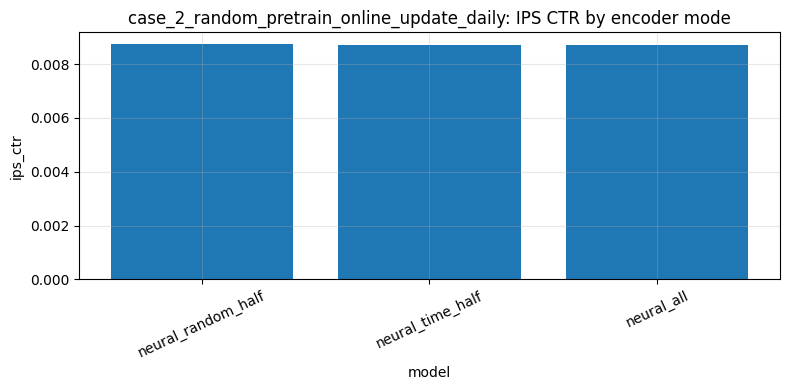

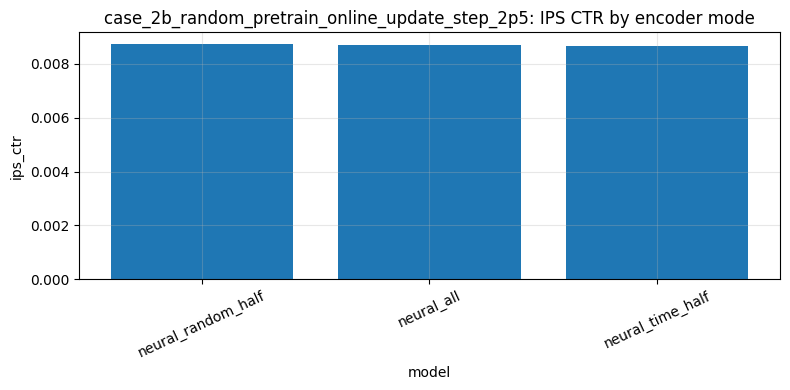

In [6]:
if not neural_metrics.empty:
    for scenario_name, part in neural_metrics.groupby('scenario'):
        fig, ax = plt.subplots(figsize=(8, 4))
        part = part.sort_values('ips_ctr', ascending=False)
        ax.bar(part['algo'], part['ips_ctr'])
        ax.set_title(f'{scenario_name}: IPS CTR by encoder mode')
        ax.set_xlabel('model')
        ax.set_ylabel('ips_ctr')
        ax.tick_params(axis='x', rotation=25)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()
else:
    print('No neural metrics to plot.')


## 7) Save comparison artifacts


In [7]:
OUT_DIR = ARTIFACTS_DIR / 'encoder_mode_compare'
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT_DIR / 'metrics_compare.csv'
history_path = OUT_DIR / 'history_compare.csv'

metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)

print('saved:', metrics_path)
print('saved:', history_path)


saved: /Users/ogrobertino/BanditsResearch/artifacts/banner_small/encoder_mode_compare/metrics_compare.csv
saved: /Users/ogrobertino/BanditsResearch/artifacts/banner_small/encoder_mode_compare/history_compare.csv
